## Pegasus Evaluation

The outline of the paper's evaluation. Every experiment states whether it can be run on

- **synthetic** data: generated service types and the queue simulator of `method_v2.ipynb`. A chain never repeats a
  service type: a seeded generator provides as many different service types as the chain is deep;
- **real** data: the testbed campaign in `statics/milos_results/` (experiment folders in brackets).

Limits of the real data that hold for every experiment:

- Per run and service, the campaign stores the mean, p50, p95 and p99 of the processing, waiting and total time, and
  for pipelines the same for the end-to-end time. Per-request traces exist only for pipelines; single-service runs
  have no per-item records.
- The copy is incomplete: many `traces.csv` and `trace_steps.csv` files and the `dataset.csv` of 01 and 03 are cut off
  in the middle of a line, 08a stopped early, and the last three experiments of the campaign are missing.
- The waiting time is several hundred milliseconds in every run, tens to hundreds of times the processing time, also at
  low load, and services run with several workers. The bounds model one FIFO server whose waiting comes from queueing
  only, so they cannot match the measured latency before that waiting is modeled.

In [1]:
# Data source of every experiment: "synthetic" (the simulated system of method_v2.ipynb) or "real" (statics/milos_results)
data_source = "synthetic"

import time
import warnings
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning

from baselines import (conformal_service_bounds, independent_snc_convolution, joint_gaussian_quantile, queueing_formula_latency,
                       summed_service_quantiles, train_dnn_models, union_bound_oracle)
from evaluation_data import load_chain_data, load_training_data, synthetic_chain
from service_gp import execution_time_belief, train_gp_models
from snc_bounds import (martingale_closed_form_node_bound, martingale_closed_form_node_bounds, network_service_bound,
                        propagated_node_bounds, snc_latency_bound)

alpha = 0.05                                           # violation probability epsilon: a bound at alpha bounds the (1 - alpha) latency quantile
confidence = 0.95                                      # the pessimistic mean of a bound lies above the true mean with this probability
coverage_check = dict(n_batches=10, confidence=0.95)   # confidence interval of a measured quantile (batch means)
seed = 35                                              # base seed of the data source
seeds = [0, 1, 2, 3, 4]                                # every experiment is repeated for these seeds; a seed determines the generated service
                                                       # types, the training data and the held-out configurations
n_calibration = 20                                     # training configurations that Conformal sets aside for calibration; the rest trains its model
p_label = f"p{100 * (1 - alpha):g}"
group_colors = {"proposed": "tab:green", "baseline": "tab:gray", "reference": "tab:purple"}
method_colors = {"Pegasus (ours)": "tab:green", "GP Sum": "tab:gray", "DNN Sum": "black", "Kingman": "tab:blue",
                 "Quantile Union": "tab:orange", "Conformal": "tab:red", "Oracle": "tab:purple"}


def tightness_figure(results, data, title):
    """One row per method of `results` (name -> (group, end-to-end latency per held-out configuration in s)): its
    tightness, latency / measured quantile, over the configurations with a finite latency."""
    names = list(results)[::-1]   # first method at the top
    colors = [group_colors[results[name][0]] for name in names]
    rows = np.arange(1, len(names) + 1)
    fig, ax = plt.subplots(figsize=(10, 0.45 * len(names) + 1.6))
    ratios = [results[name][1] / data.measured for name in names]
    boxes = ax.boxplot([ratio[np.isfinite(ratio)] for ratio in ratios], positions=rows, vert=False, patch_artist=True, widths=0.6,
                       medianprops=dict(color="black"), flierprops=dict(markersize=3))
    for box, color in zip(boxes["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)
    ax.axvline(1.0, color="black", linewidth=1)
    ax.set_xscale("log")
    ax.set_xticks([0.25, 0.5, 1, 2, 4, 8], ["0.25×", "0.5×", "1×", "2×", "4×", "8×"])
    ax.minorticks_off()
    ax.set_xlabel(f"tightness: end-to-end latency ÷ measured {p_label} (log scale)")
    ax.set_yticks(rows, names)
    ax.grid(True, axis="x", linestyle=":", alpha=0.6)
    groups = [group for group in group_colors if any(results[name][0] == group for name in names)]
    fig.legend([plt.Rectangle((0, 0), 1, 1, color=group_colors[group], alpha=0.7) for group in groups], groups,
               loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=len(groups))
    fig.suptitle(f"{title}, {data_source} data: {' → '.join(data.path)}, {len(data.x_test)} held-out configurations,\n"
                 f"{data.workload['process']} arrivals at {data.workload['rate']:g}/s")
    plt.tight_layout()
    plt.show()


def fit_services(data, x_train, y_train, model_seed):
    """Per-service models of the execution time, trained on single-service data: a GP and a DNN per service, and the
    beliefs Pegasus builds from the GPs at the held-out configurations of `data`, per position of its chain (a
    pessimistic mean with a per-item variance, and the optimistic mean that the propagated bounds need). "seconds" holds
    the time it took to train the GPs and the DNNs. model_seed: seed of the DNN training."""
    services = sorted(set(data.path))
    started = time.perf_counter()
    gp = train_gp_models(x_train, y_train, services)
    gp_seconds = time.perf_counter() - started
    started = time.perf_counter()
    dnn = train_dnn_models(x_train, y_train, services, seed=model_seed)
    dnn_seconds = time.perf_counter() - started
    belief = {s: execution_time_belief(gp[s], data.x_test, confidence) for s in services}
    lower_mean = {s: execution_time_belief(gp[s], data.x_test, 1 - confidence)[0] for s in services}
    return dict(gp=gp, dnn=dnn, seconds=dict(gp=gp_seconds, dnn=dnn_seconds),
                beliefs=[belief[s] for s in data.path], lower_means=[lower_mean[s] for s in data.path])


def pegasus_bound(data, models):
    """Pegasus: the union bound over the closed-form martingale node bounds with propagated service spacing, per
    held-out configuration (s). The waiting time at a service is bounded by Kingman's martingale bound exp(-theta w);
    with a Gaussian execution time, the latency bound of the service follows from one formula. The first service
    receives the external arrivals; every later one receives the departures of the service before it, which cannot be
    closer together than that service's execution times. Every position of the chain gets its own node bound."""
    K = len(data.path)
    return martingale_closed_form_node_bounds(models["beliefs"], models["lower_means"], epsilon=alpha / K, **data.workload).sum(axis=0)


def compare_methods(data, models, x_train, monitored_latencies, n_calibration, model_seed):
    """Pegasus, every baseline and the reference for the chain of `data` at its held-out configurations. Returns two
    dictionaries: name -> (group, end-to-end latency per configuration in s), and name -> (seconds to train the models
    the method uses, seconds to compute its latency at the held-out configurations); the reference has no time.
    models: from fit_services; x_train, monitored_latencies: the training configurations and the latencies of every
    service monitored alone at them (None leaves out the baselines that need them). The union bound gives every service
    the share alpha / K of the violation probability. model_seed: seed of the calibration split of Conformal."""
    K, workload = len(data.path), data.workload
    predictions = lambda fitted: [fitted[s].predict(data.x_test, return_std=True) for s in data.path]
    gp_seconds, dnn_seconds = models["seconds"]["gp"], models["seconds"]["dnn"]
    # name, group, time to train the models the method shares with others, function that computes its latencies
    candidates = [
        ("Pegasus (ours)", "proposed", gp_seconds, lambda: pegasus_bound(data, models)),
        ("GP Sum", "baseline", gp_seconds, lambda: joint_gaussian_quantile(*zip(*predictions(models["gp"])), norm.ppf(1 - alpha))),
        ("DNN Sum", "baseline", dnn_seconds, lambda: joint_gaussian_quantile(*zip(*predictions(models["dnn"])), norm.ppf(1 - alpha))),
        ("Kingman", "baseline", gp_seconds, lambda: sum(queueing_formula_latency(mean, std ** 2, epsilon=alpha, **workload)
                                                        for mean, std in predictions(models["gp"]))),
    ]
    if monitored_latencies is not None:   # these two train their own models, so their training time is part of the computation
        candidates.append(("Quantile Union", "baseline", 0.0, lambda: summed_service_quantiles(x_train, monitored_latencies, data.path, alpha / K, data.x_test)))
        if len(x_train) - n_calibration >= 5:   # Conformal needs configurations left to train its model on
            candidates.append(("Conformal", "baseline", 0.0, lambda: conformal_service_bounds(
                x_train, monitored_latencies, data.path, alpha, data.x_test, miscoverage=1 - confidence, n_calibration=n_calibration, seed=model_seed)))
    methods, seconds = {}, {}
    for name, group, training_seconds, compute in candidates:
        started = time.perf_counter()
        methods[name] = (group, compute())
        seconds[name] = (training_seconds, time.perf_counter() - started)
    if data.node_latencies is not None:         # reference: what a union bound reaches with measured instead of predicted nodes
        methods["Oracle"] = ("reference", union_bound_oracle(data.node_latencies, alpha))
    return methods, seconds

## A. Experimental Setup

### Service Generation

- **Synthetic:** yes. `synthetic_service` in `evaluation_data.py` generates every service type from the seed
  `service_seed`: an execution-time function and a noise level with randomly drawn parameters. A chain of depth K
  consists of the first K service types (`synthetic_chain`), so no service type occurs twice in a chain.
- **Real:** yes. Every service is measured alone (02a–h, 07a–f) and inside chains (04a–h, 06a–b), each service with
  its own configuration. Unseen configurations and unseen compositions are both possible: train on the single-service
  runs, test on the chains.

### Sampling Strategies

- **Synthetic:** uniform random yes; active learning and grid search possible, not implemented.
- **Real:** uniform random only, because the campaign drew its configurations at random. Active learning and grid
  search only as a selection among the measured runs.

### Baselines

Every baseline is trained on data of each service on its own, like the proposed method; none sees a run of the chain.

- **Synthetic:** yes. Execution-time model per service, summed, without queue (GP, DNN); queueing formula per service, summed; latency quantile per
  service with split budget, without and with a conformal step. All are in `baselines.py`.
- **Real:** yes for the execution-time models and the queueing formula (processing times of 02a–h, 07a–f). The latency-quantile baselines need the
  latency quantile of every service alone under load: the single-service runs store p95 and p99, so only these two
  levels are available.

## B. Coverage and Tightness of Service Bounds

### B.1 Base Case

- **Synthetic:** yes (`method_v2.ipynb`, Sections 7g and 9).
- **Real:** yes. Chain qr → cv → face (04e), with the models of its services trained on 07a–c.
- **Baselines:** the three per-service categories of A (execution-time model summed, with GP and DNN; queueing formula per
  service; latency quantile per service with split budget, without and with a conformal step), and the union bound over measured nodes as reference.

**Setting.** The chain $s_1 \to s_2 \to s_3$ with every service at the same configuration, at held-out configurations
drawn from the training range; no held-out configuration occurs in the training data of any model. The ground truth
is the measured $(1-\varepsilon)$ quantile of the end-to-end latency of the chain, with $\varepsilon$ = `alpha`. The
experiment is repeated for every seed in `seeds`: a seed determines the three generated service types, the training
data and the held-out configurations. The figures and the conclusion pool the held-out configurations of all seeds.

**Training data.** Every method is trained on data of each service on its own and never on a run of the chain. The
proposed method, the two execution-time baselines and the queueing formula use one execution time per service and training configuration.
Quantile Union and Conformal use the latencies (waiting plus execution) of each service monitored alone under the
arrival process of the workload, at the same training configurations.

**Metrics.** *Tightness* of a method at a configuration is its end-to-end latency ÷ the measured quantile: 1 is exact,
above 1 is looser, below 1 is under the measured quantile. *Coverage* is the share of configurations at which a method
is not below the lower edge of the confidence interval of the measured quantile (`coverage_check`).

**Methods.**
- *Pegasus (ours):* the union bound over martingale node bounds in closed form. The waiting time at a service is
  bounded by Kingman's martingale bound, an exponential tail whose rate follows from the moment generating function of
  the service's execution time and from its arrivals; with a Gaussian execution time, the latency bound of the service
  is then one formula. The first service receives the external arrivals, and every later service the departures of
  the service before it, which cannot be closer together than that service's execution times.
- *GP Sum, DNN Sum (baselines; execution-time model per service, summed, no queue):* the $(1-\varepsilon)$ quantile of the sum of the
  predicted execution times, with a GP and with a neural network (DNN) per service.
- *Kingman (baseline; queueing formula per service, summed):* the GP's mean and variance of the execution time enter a textbook
  formula for one queue (Kingman's approximation of the mean waiting time, an exponential waiting-time tail), which
  gives the $(1-\varepsilon)$ latency quantile of each service; the quantiles are added.
- *Quantile Union (baseline; latency quantile per service, split budget):* one GP per service predicts the
  $(1-\varepsilon/K)$ latency quantile of the service alone under load, for a chain of $K$ services; the predictions
  are added. This is the union bound applied to point predictions, trained on all training configurations.
  *Note:* the arrival rate is not an input of this model, so the model holds only for the workload its services were
  monitored under. With the arrival rate as an input (as in Fluxion), samples from existing executions at other loads
  could be reused for a new composition. The model would still not know that later services of a chain queue less:
  every service of a chain receives the same rate, and what changes is how evenly the arrivals are spaced.
- *Conformal (baseline; Quantile Union with a conformal step):* the same model, trained on the training
  configurations except `n_calibration` of them, on which a correction factor is calibrated (the ratio measured ÷
  predicted quantile). Every prediction is multiplied by that factor, so that it holds per service with probability
  `confidence`; the bounds of the services are added.
- *Oracle (reference):* the union bound over the measured latency quantiles of the services in the chain; it uses the ground
  truth and is not a competitor.

In [2]:
# Data of the chain and the per-service models for every seed, all trained on single-service data
bases, base_models = {}, {}
for s in seeds:
    bases[s] = load_chain_data(data_source, path=synthetic_chain(3), level=1 - alpha, coverage_check=coverage_check, seed=[seed, s], service_seed=s)
    assert not (bases[s].x_test[:, None, :] == bases[s].x_train[None, :, :]).all(axis=2).any(), "a held-out configuration occurs in the training data"
    base_models[s] = fit_services(bases[s], bases[s].x_train, bases[s].y_train, model_seed=seed + s)
base = bases[seeds[0]]   # for what is the same under every seed: the names in the chain, the workload, the numbers of configurations
K, workload = len(base.path), base.workload
print(f"{data_source} data, {len(seeds)} seeds: chain {' -> '.join(base.path)}, per seed {len(base.x_train)} training and {len(base.x_test)} held-out "
      f"configurations, {workload['process']} arrivals at {workload['rate']:g} items/s")

synthetic data, 5 seeds: chain s1 -> s2 -> s3, per seed 50 training and 100 held-out configurations, poisson arrivals at 4 items/s


In [3]:
def base_case(s):
    """Every method, and every composition of the ablation, for the chain of the seed s: two dictionaries
    name -> (group, end-to-end latency per held-out configuration in s)."""
    data, models = bases[s], base_models[s]
    methods, _ = compare_methods(data, models, data.x_train, data.monitored_latencies, n_calibration, model_seed=seed + s)
    beliefs, lower_means = models["beliefs"], models["lower_means"]
    # Ablation: the other ways to bound the nodes and to compose them, all on the same GP beliefs
    compositions = {
        "union bound, Chernoff (SNC) nodes": ("proposed", sum(snc_latency_bound(*b, epsilon=alpha / K, **workload) for b in beliefs)),
        "union bound, propagated Chernoff (SNC) nodes": ("proposed", propagated_node_bounds(beliefs, epsilon=alpha / K, path_lower_means=lower_means, **workload).sum(axis=0)),
        "union bound, martingale nodes": ("proposed", sum(martingale_closed_form_node_bound(*b, epsilon=alpha / K, **workload) for b in beliefs)),
        "union bound, propagated martingale nodes = Pegasus": ("proposed", methods["Pegasus (ours)"][1]),
        "network service curve (Hölder)": ("proposed", network_service_bound(beliefs, epsilon=alpha, **workload)),
        "independent SNC convolution (no guarantee)": ("baseline", independent_snc_convolution(beliefs, alpha, **workload)),
    }
    return methods, compositions


def pooled(results):
    """One dictionary name -> (group, latencies) from one per seed: the held-out configurations of all seeds, one seed after the other."""
    return {name: (results[0][name][0], np.concatenate([result[name][1] for result in results])) for name in results[0]}


per_seed = [base_case(s) for s in seeds]
methods, compositions = pooled([m for m, _ in per_seed]), pooled([c for _, c in per_seed])
proposed = methods["Pegasus (ours)"][1]
# the ground truth of all seeds in the same order as the pooled latencies
base_pooled = SimpleNamespace(path=base.path, workload=workload, x_test=np.concatenate([bases[s].x_test for s in seeds]),
                              measured=np.concatenate([bases[s].measured for s in seeds]),
                              measured_low=np.concatenate([bases[s].measured_low for s in seeds]))
print(f"{len(methods)} methods and {len(compositions)} compositions computed for {len(seeds)} seeds.")

7 methods and 6 compositions computed for 5 seeds.


**Figures.** Both figures have one row per method and show its tightness over the held-out configurations on a
logarithmic axis (box: quartiles, line: median, whiskers and points: the remaining configurations; configurations
without a finite latency are left out). The vertical line at 1× is the measured quantile: a value to the left of
that line is below the measured quantile. The first figure compares the proposed method with the
baselines. The second is an ablation: every way to bound the nodes and to compose them on the same GP models. Pegasus is its
fourth row; the independent SNC convolution is the only row without a guarantee.

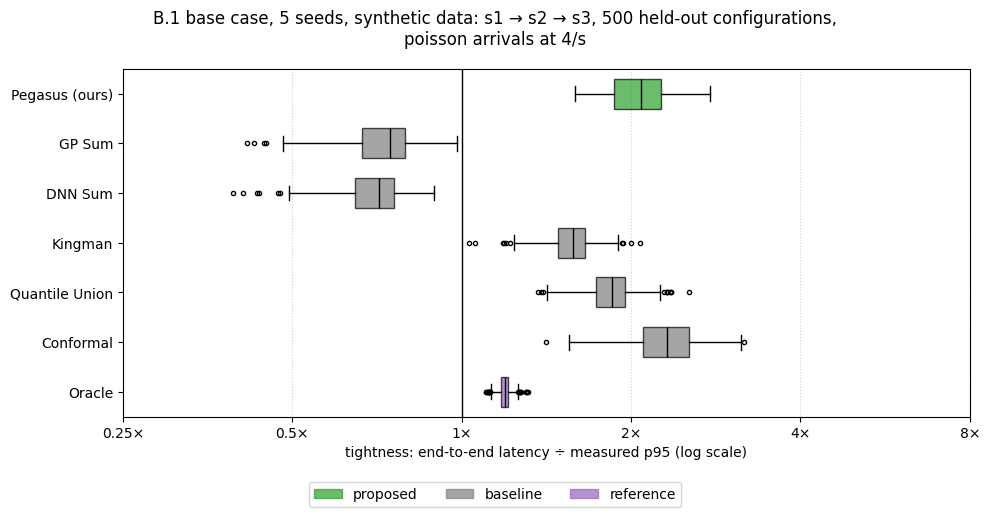

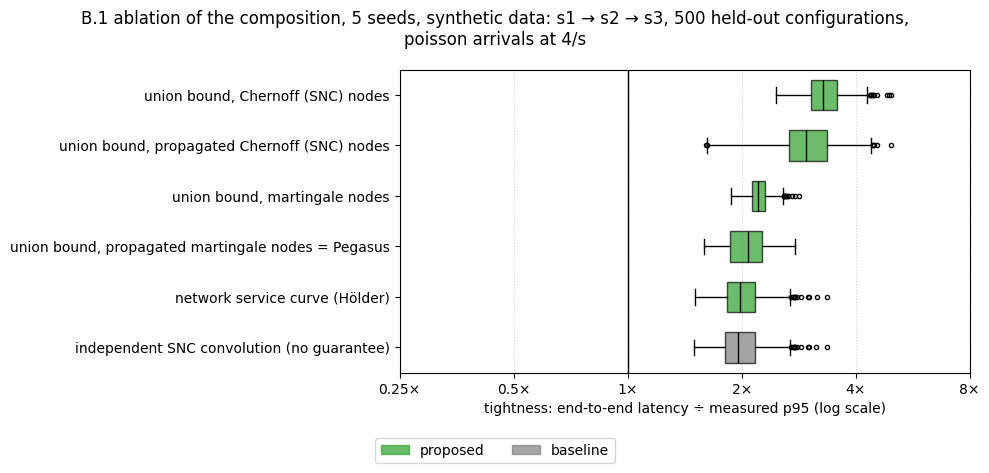

In [4]:
tightness_figure(methods, base_pooled, f"B.1 base case, {len(seeds)} seeds")
tightness_figure(compositions, base_pooled, f"B.1 ablation of the composition, {len(seeds)} seeds")

In [5]:
covers = lambda latency: np.mean(latency >= base_pooled.measured_low) >= confidence
median = lambda latency: np.median(latency / base_pooled.measured)
baseline_names = [name for name, (group, _) in methods.items() if group == "baseline"]
covering = [name for name in baseline_names if covers(methods[name][1])]
tighter = [name for name in covering if median(methods[name][1]) < median(proposed)]
display(Markdown(
    f"**What this shows** ({data_source} data, {workload['process']} arrivals at {workload['rate']:g} items/s, ε = {alpha:g}, the held-out configurations of {len(seeds)} seeds together).\n"
    f"- Pegasus {'reaches' if covers(proposed) else 'does not reach'} the confidence level. "
    f"Of the {len(baseline_names)} baselines, {len(covering)} reach it"
    + (f" ({', '.join(covering)}), and {len(tighter)} of those {'is' if len(tighter) == 1 else 'are'} tighter than Pegasus"
       + (f" ({', '.join(tighter)})" if tighter else "") if covering else "")
    + ".\n"
    f"- {sum(covers(latency) for group, latency in compositions.values() if group == 'proposed')} of the "
    f"{sum(group == 'proposed' for group, _ in compositions.values())} compositions with a guarantee reach the confidence level."
))

**What this shows** (synthetic data, poisson arrivals at 4 items/s, ε = 0.05, the held-out configurations of 5 seeds together).
- Pegasus reaches the confidence level. Of the 5 baselines, 3 reach it (Kingman, Quantile Union, Conformal), and 2 of those are tighter than Pegasus (Kingman, Quantile Union).
- 5 of the 5 compositions with a guarantee reach the confidence level.

### B.2 Varying Evidence per Service

- **Synthetic:** yes, by varying `n_train`. The simulator cannot test the transfer between compositions, because a
  service's execution time does not depend on the chain there.
- **Real:** yes. Subsample the single-service runs (02a–h, 07a–f). The same services are also measured inside other
  compositions (trees 01 and 03, other chains), which gives training data from a composition different from the target.
- **Baselines:** as in B.1, each with the same number of single-service runs as the proposed method.


**Setting.** For every seed, the chain, the held-out configurations and the ground truth of B.1. Only the
single-service training data changes: `evidence_sizes` training configurations per service, drawn anew for every size
and seed. No held-out configuration occurs in any of them. Conformal sets aside the same share of its configurations
for calibration as in B.1, and at least 19, the fewest that give it a finite bound; it is left out where fewer than 5
configurations would remain to train its model. The Oracle uses no training data.

**Complexity (analyzed here, against the amount of training data).** The *computing time* of a method is the time to
train the models it uses and to compute its end-to-end latency at the held-out configurations, in seconds on the
machine that ran the notebook. It does not contain the time to collect the training data: one execution time per
service and configuration for Pegasus, GP Sum, DNN Sum and Kingman, a run under load per service and configuration
for Quantile Union and Conformal. The complexity against the depth of the chain is analyzed in B.3.

**Figure.** The horizontal axis is the number of training configurations per service (logarithmic). *Left:* tightness,
for every seed the median over its held-out configurations; the horizontal line at 1× is the measured quantile, and a
value under that line is below the measured quantile. *Right:* computing time (s, logarithmic). Every line is the
median over the seeds, and the band around it reaches from the smallest to the largest seed.

In [6]:
# B.2: the chains of B.1 with single-service training data of different sizes
evidence_sizes = [10, 15, 25, 50, 100, 200]             # training configurations per service
calibration_share = n_calibration / len(base.x_train)   # share that Conformal sets aside for calibration, as in B.1
evidence, evidence_seconds = {}, {}                     # (size, seed) -> name -> (group, latency per held-out configuration) / computing time in s
with warnings.catch_warnings():
    # with few training configurations the fitted GP hyperparameters often end at their bounds, and scikit-learn warns for every model
    warnings.simplefilter("ignore", ConvergenceWarning)
    for size in evidence_sizes:
        for s in seeds:
            x_train, y_train, monitored = load_training_data(data_source, services=bases[s].path, workload=workload, n_train=size,
                                                             seed=[seed, s, size], service_seed=s)
            assert not (bases[s].x_test[:, None, :] == x_train[None, :, :]).all(axis=2).any(), "a held-out configuration occurs in the training data"
            evidence[(size, s)], evidence_seconds[(size, s)] = compare_methods(
                bases[s], fit_services(bases[s], x_train, y_train, model_seed=seed + s), x_train, monitored,
                n_calibration=max(19, round(calibration_share * size)), model_seed=seed + s)
print(f"{len(evidence)} training sets evaluated.")

30 training sets evaluated.


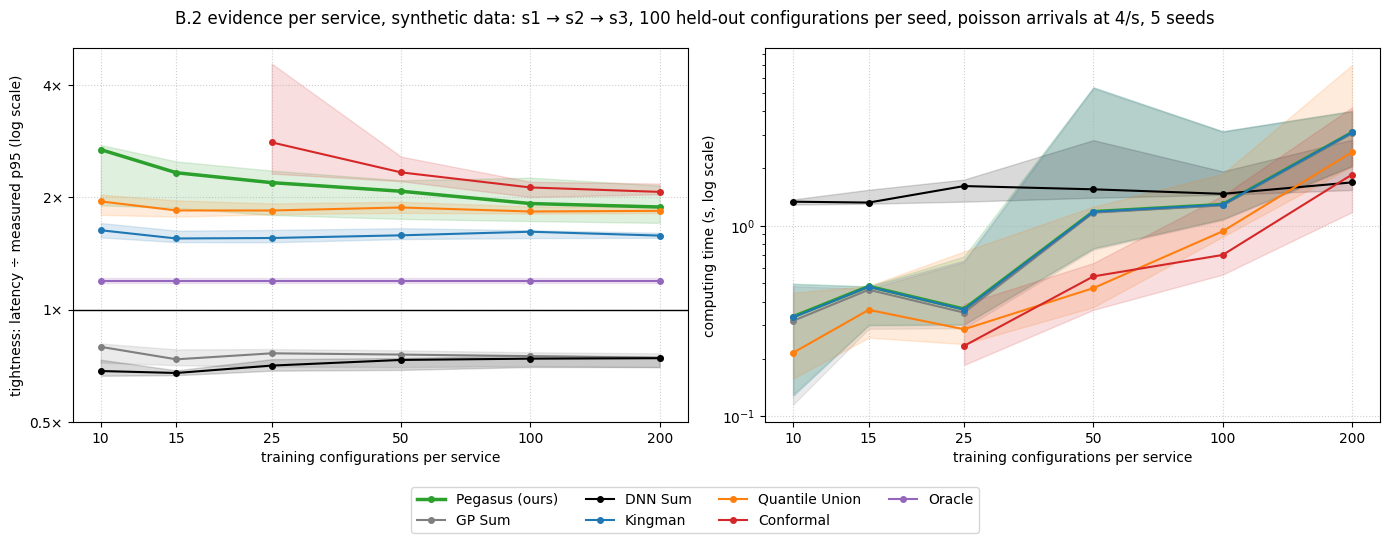

In [7]:
def over_evidence(name, statistic):
    """statistic(latency, data of the seed) of a method for every size and seed, (sizes, seeds); nan where the method was left out."""
    return np.array([[statistic(evidence[(size, s)][name][1], bases[s]) if name in evidence[(size, s)] else np.nan for s in seeds]
                     for size in evidence_sizes])


evidence_coverage = {name: over_evidence(name, lambda latency, data: np.mean(latency >= data.measured_low)) for name in method_colors}
evidence_tightness = {name: over_evidence(name, lambda latency, data: np.median(latency / data.measured)) for name in method_colors}
evidence_time = {name: np.array([[sum(evidence_seconds[(size, s)].get(name, (np.nan, np.nan))) for s in seeds] for size in evidence_sizes])
                 for name in method_colors if name != "Oracle"}

fig, (ax_tight, ax_time) = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, values in ((ax_tight, evidence_tightness), (ax_time, evidence_time)):
    for name, color in method_colors.items():
        if name not in values:
            continue
        shown = ~np.isnan(values[name]).all(axis=1)
        sizes = np.array(evidence_sizes)[shown]
        ax.plot(sizes, np.nanmedian(values[name][shown], axis=1), "o-", color=color, label=name, linewidth=2.5 if name == "Pegasus (ours)" else 1.5, markersize=4)
        ax.fill_between(sizes, np.nanmin(values[name][shown], axis=1), np.nanmax(values[name][shown], axis=1), color=color, alpha=0.15)
    ax.set_xscale("log")
    ax.set_xticks(evidence_sizes, [str(size) for size in evidence_sizes])
    ax.minorticks_off()
    ax.set_xlabel("training configurations per service")
    ax.grid(True, linestyle=":", alpha=0.6)
ax_tight.axhline(1.0, color="black", linewidth=1)
ax_tight.set_yscale("log")
ax_tight.set_yticks([0.5, 1, 2, 4], ["0.5×", "1×", "2×", "4×"])
ax_tight.minorticks_off()
ax_tight.set_ylabel(f"tightness: latency ÷ measured {p_label} (log scale)")
ax_time.set_yscale("log")
ax_time.set_ylabel("computing time (s, log scale)")
handles, labels = ax_tight.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=4)
fig.suptitle(f"B.2 evidence per service, {data_source} data: {' → '.join(base.path)}, {len(base.x_test)} held-out configurations per seed, "
             f"{workload['process']} arrivals at {workload['rate']:g}/s, {len(seeds)} seeds")
plt.tight_layout()
plt.show()

In [8]:
typical = lambda values, name: np.array([np.nan if np.isnan(row).all() else np.nanmedian(row) for row in values[name]])   # per size, median over the seeds
pegasus_coverage, pegasus_tightness = typical(evidence_coverage, "Pegasus (ours)"), typical(evidence_tightness, "Pegasus (ours)")
failing = {name: [size for size, value in zip(evidence_sizes, typical(evidence_coverage, name)) if value < confidence]
           for name, (group, _) in methods.items() if group == "baseline"}
display(Markdown(
    f"**What this shows** ({data_source} data, {workload['process']} arrivals at {workload['rate']:g} items/s, ε = {alpha:g}, median over "
    f"{len(seeds)} seeds).\n"
    f"- Pegasus reaches the confidence level at {int(np.sum(pegasus_coverage >= confidence))} of the {len(evidence_sizes)} sizes. Its tightness goes from "
    f"{pegasus_tightness[0]:.2f}× with {evidence_sizes[0]} training configurations to {pegasus_tightness[-1]:.2f}× with {evidence_sizes[-1]}.\n"
    f"- Baselines below the confidence level, and at which sizes: "
    + ("; ".join(f"{name} at {'every size' if len(sizes) == len(evidence_sizes) else ', '.join(map(str, sizes))}" for name, sizes in failing.items() if sizes)
       or "none")
    + ".\n"
    f"- Computing time with {evidence_sizes[-1]} training configurations: "
    + ", ".join(f"{name} {seconds:.2g} s" for name, seconds in sorted(((name, typical(evidence_time, name)[-1]) for name in evidence_time), key=lambda item: -item[1]))
    + f". For Pegasus it is {typical(evidence_time, 'Pegasus (ours)')[0]:.2g} s with {evidence_sizes[0]}."
))

**What this shows** (synthetic data, poisson arrivals at 4 items/s, ε = 0.05, median over 5 seeds).
- Pegasus reaches the confidence level at 6 of the 6 sizes. Its tightness goes from 2.69× with 10 training configurations to 1.88× with 200.
- Baselines below the confidence level, and at which sizes: GP Sum at every size; DNN Sum at every size.
- Computing time with 200 training configurations: Kingman 3.1 s, Pegasus (ours) 3.1 s, GP Sum 3.1 s, Quantile Union 2.4 s, Conformal 1.9 s, DNN Sum 1.7 s. For Pegasus it is 0.33 s with 10.

### B.3 Varying Chain Depth

- **Synthetic:** yes.
- **Real:** partly. Depth 1 (02a–h, 07a–f), 2 (04a–d), 3 (04e–f), 4 (04g), 5 (04h) and 10 (06a–b). Nothing at 20
  or 50.
- **Baselines:** as in B.1. The conformal bound splits its budget over the services, like the union bound.

**Setting.** Chains of depth $K$ (`depths`) of $K$ different service types, $s_1 \to s_2 \to \dots \to s_K$
(`synthetic_chain`): the chain of depth 3 is the chain of B.1, and every deeper chain adds further service types.
Every position has its own queue, and all positions run at the same configuration. The training configurations and
the held-out configurations are those of B.1 at every depth, every service has its own training data, and the ground
truth is simulated anew for every depth. All of this is repeated for every seed in `seeds`. Metrics and methods are those of B.1.

Two things change with the depth for every method that splits the violation budget (Pegasus, Quantile Union,
Conformal, Oracle): each service is bounded at the level $1 - \varepsilon / K$, which moves further into the tail as $K$
grows. The runs that Quantile Union, Conformal and the Oracle read that quantile from have a fixed number of items, so
for the deepest chains only a handful of items lie beyond it and their values rest on very few observations.

**Complexity (analyzed here, against the depth).** A node bound of Pegasus is one formula and a short search on it,
so its computing time does not depend on the budget ε / K of a service. Every position of a chain gets its own node
bound: the computing time of Pegasus is expected to grow linearly with K. The *computing time* here is the time to compute a method's end-to-end latency
at the held-out configurations. It does not contain the training of the execution-time models, of which there is one
per service, so that their training time grows linearly with the depth as well; Quantile Union and Conformal train
their own model per service and depth, which is part of their time.

**Figure.** The horizontal axis is the depth $K$ (logarithmic). *Left:* tightness, for every seed the median over its
held-out configurations. The horizontal line at 1× is the measured quantile: a value under that line is below the
measured quantile. *Right:* computing time (s, logarithmic). Every line is the median over the seeds, and the band
around it reaches from the smallest to the largest seed.

**Figure (minimum spacing).** A second figure, below the conclusion, shows the deepest chain of the first seed position
by position: the
processing time of every service (the mean execution time that its GP predicts, in ms) and the *minimum spacing* of its
arrivals. The minimum spacing is the smallest gap that two consecutive items can have when they arrive at the service.
It equals the processing time of the service before, because that service handles one item at a time and so cannot
release two items closer together than it needs for one. The actual gaps are usually larger. Lines are the median over
the held-out configurations, bands the first to third quartile. Where the minimum spacing lies below the processing
time, the service sits behind a faster one: items can arrive faster than it processes them for a while, and it can
queue; these positions are circled. The title gives two shares over all later positions and held-out configurations:
how often the service before is faster, and how often Pegasus cannot use the minimum spacing, which is more often,
because Pegasus requires the optimistic mean of the service before to exceed the pessimistic mean of the service itself.
In those cases Pegasus falls back on the external arrivals.

In [9]:
# B.3: chains of different depth, every position a different service type, at the held-out configurations of B.1
depths = [1, 2, 5, 10, 20, 50]
depth_truth, depth_methods, depth_seconds = {}, {}, {}   # (seed, depth) -> ...
with warnings.catch_warnings():
    # for some services the fitted GP hyperparameters end at their bounds, and scikit-learn warns for every such model
    warnings.simplefilter("ignore", ConvergenceWarning)
    for s in seeds:
        for depth in depths:
            data = load_chain_data(data_source, path=synthetic_chain(depth), level=1 - alpha, coverage_check=coverage_check, seed=[seed, s], service_seed=s)
            assert np.array_equal(data.x_test, bases[s].x_test), "the held-out configurations differ from those of B.1"
            assert not (data.x_test[:, None, :] == data.x_train[None, :, :]).all(axis=2).any(), "a held-out configuration occurs in the training data"
            models = fit_services(data, data.x_train, data.y_train, model_seed=seed + s)
            depth_methods[(s, depth)], depth_seconds[(s, depth)] = compare_methods(data, models, data.x_train, data.monitored_latencies, n_calibration,
                                                                                   model_seed=seed + s)
            depth_truth[(s, depth)] = (data.measured, data.measured_low)   # the traces of a deep chain are large, so only the measured quantile is kept
            if s == seeds[0] and depth == depths[-1]:   # one deepest chain, for the figure of the minimum spacing
                deepest_path, deepest_models, deepest_x_test = data.path, models, data.x_test
        print(f"seed {s}: depths up to {depths[-1]} evaluated")

seed 0: depths up to 50 evaluated


seed 1: depths up to 50 evaluated


seed 2: depths up to 50 evaluated


seed 3: depths up to 50 evaluated


seed 4: depths up to 50 evaluated


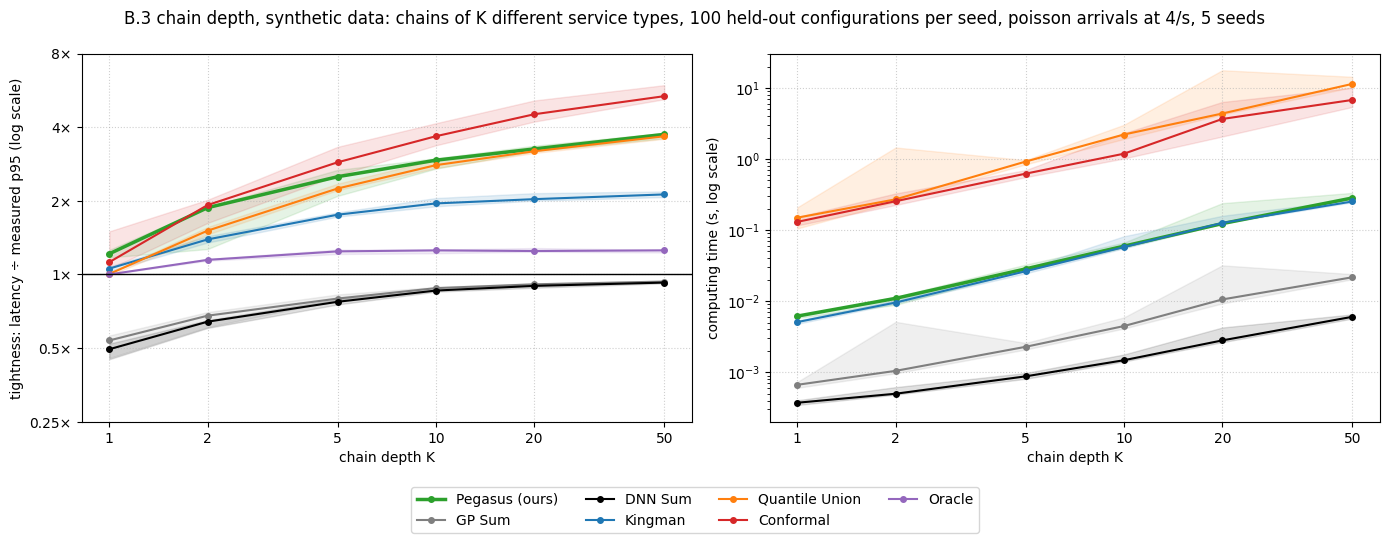

In [10]:
def over_depths(name, statistic):
    """statistic(latency, measured, measured_low) of a method for every seed and depth, (seeds, depths); infinite values become nan."""
    values = np.array([[statistic(depth_methods[(s, depth)][name][1], *depth_truth[(s, depth)]) for depth in depths] for s in seeds], dtype=float)
    return np.where(np.isfinite(values), values, np.nan)


depth_coverage = lambda latency, measured, low: np.mean(latency >= low)
depth_tightness = lambda latency, measured, low: np.median(latency / measured)
depth_styles = {name: dict(color=color, linestyle="-", linewidth=2.5 if name == "Pegasus (ours)" else 1.5) for name, color in method_colors.items()}
depth_time = {name: np.array([[depth_seconds[(s, depth)][name][1] for depth in depths] for s in seeds]) for name in depth_seconds[(seeds[0], depths[0])]}

fig, (ax_tight, ax_time) = plt.subplots(1, 2, figsize=(14, 4.8))
for name, style in depth_styles.items():
    for ax, values in ((ax_tight, over_depths(name, depth_tightness)), (ax_time, depth_time.get(name))):
        if values is not None:   # line: median over the seeds; band: smallest to largest seed
            ax.plot(depths, np.nanmedian(values, axis=0), marker="o", markersize=4, label=name, **style)
            ax.fill_between(depths, np.nanmin(values, axis=0), np.nanmax(values, axis=0), color=style["color"], alpha=0.12)
for ax in (ax_tight, ax_time):
    ax.set_xscale("log")
    ax.set_xticks(depths, [str(depth) for depth in depths])
    ax.minorticks_off()
    ax.set_xlabel("chain depth K")
    ax.grid(True, linestyle=":", alpha=0.6)
ax_tight.axhline(1.0, color="black", linewidth=1)
ax_tight.set_yscale("log")
ax_tight.set_yticks([0.25, 0.5, 1, 2, 4, 8], ["0.25×", "0.5×", "1×", "2×", "4×", "8×"])
ax_tight.minorticks_off()
ax_tight.set_ylabel(f"tightness: latency ÷ measured {p_label} (log scale)")
ax_time.set_yscale("log")
ax_time.set_ylabel("computing time (s, log scale)")
handles, labels = ax_tight.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=4)
fig.suptitle(f"B.3 chain depth, {data_source} data: chains of K different service types, {len(base.x_test)} held-out configurations per seed, "
             f"{workload['process']} arrivals at {workload['rate']:g}/s, {len(seeds)} seeds")
plt.tight_layout()
plt.show()

In [11]:
depth_cover = {name: over_depths(name, depth_coverage) for name in depth_styles}                                   # (seeds, depths)
depth_median = {name: np.nanmedian(over_depths(name, depth_tightness), axis=0) for name in depth_styles}          # per depth, median over the seeds
pegasus_reaches = depth_cover["Pegasus (ours)"] >= confidence
below = {name: {depth: int(np.sum(~(depth_cover[name][:, k] >= confidence))) for k, depth in enumerate(depths)}   # per depth, number of seeds below the level
         for name, (group, _) in depth_methods[(seeds[0], depths[0])].items() if group == "baseline"}
computing = {name: np.median(times, axis=0) for name, times in depth_time.items()}                                  # per depth, median over the seeds
growth = lambda seconds: np.log(seconds[-1] / seconds[-2]) / np.log(depths[-1] / depths[-2])   # exponent of K between the two deepest chains
slowest_baseline = max((name for name in computing if name != "Pegasus (ours)"), key=lambda name: computing[name][-1])


def where_below(counts):
    if all(count == len(seeds) for count in counts.values()):
        return "at every depth under every seed"
    return ", ".join(f"at depth {depth} under {count} of {len(seeds)} seeds" for depth, count in counts.items() if count)


display(Markdown(
    f"**What this shows** ({data_source} data, {workload['process']} arrivals at {workload['rate']:g} items/s, ε = {alpha:g}, {len(seeds)} seeds).\n"
    f"- Pegasus reaches the confidence level in {int(pegasus_reaches.sum())} of the {pegasus_reaches.size} combinations of seed and depth. Its tightness, the "
    f"median over the seeds, is {depth_median['Pegasus (ours)'][0]:.2f}× at depth {depths[0]} and {depth_median['Pegasus (ours)'][-1]:.2f}× at depth {depths[-1]}; "
    f"the Oracle, the union bound over measured services, is at {depth_median['Oracle'][0]:.2f}× and {depth_median['Oracle'][-1]:.2f}×.\n"
    f"- Baselines below the confidence level: "
    + ("; ".join(f"{name} {where_below(counts)}" for name, counts in below.items() if any(counts.values())) or "none")
    + ".\n"
    f"- Computing time at depth {depths[-1]}, median over the seeds: Pegasus {computing['Pegasus (ours)'][-1]:.3g} s, the slowest baseline ({slowest_baseline}) "
    f"{computing[slowest_baseline][-1]:.2g} s. Between the two deepest chains the time of Pegasus grows with K to the power {growth(computing['Pegasus (ours)']):.1f}."
))

**What this shows** (synthetic data, poisson arrivals at 4 items/s, ε = 0.05, 5 seeds).
- Pegasus reaches the confidence level in 30 of the 30 combinations of seed and depth. Its tightness, the median over the seeds, is 1.21× at depth 1 and 3.74× at depth 50; the Oracle, the union bound over measured services, is at 1.00× and 1.25×.
- Baselines below the confidence level: GP Sum at every depth under every seed; DNN Sum at every depth under every seed; Kingman at depth 1 under 3 of 5 seeds; Quantile Union at depth 1 under 5 of 5 seeds.
- Computing time at depth 50, median over the seeds: Pegasus 0.283 s, the slowest baseline (Quantile Union) 11 s. Between the two deepest chains the time of Pegasus grows with K to the power 0.9.

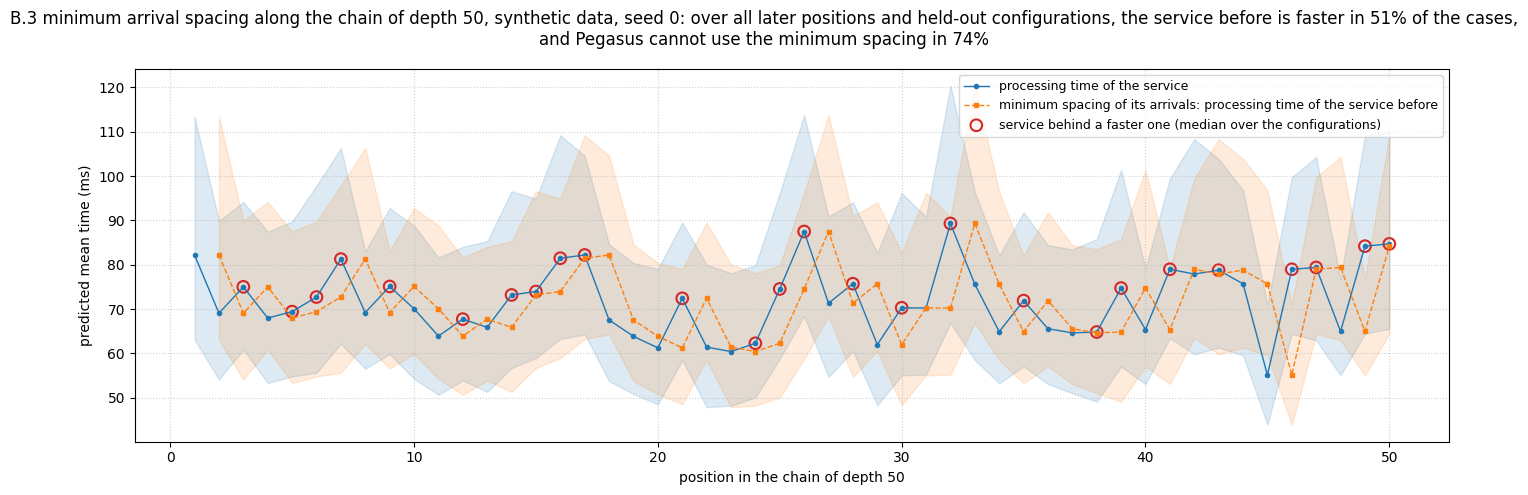

In [12]:
# The deepest chain: processing time of every service and minimum spacing of its arrivals, as the models predict them
processing = np.array([deepest_models["gp"][s].predict(deepest_x_test) for s in deepest_path]) * 1e3   # (positions, configurations), ms
spacing = processing[:-1]                                    # minimum spacing of the arrivals at the positions 2, 3, ...: processing time of the service before
behind_faster = np.mean(spacing < processing[1:], axis=1)    # share of the held-out configurations, per position
pessimistic_mean = np.array([mean for mean, _ in deepest_models["beliefs"]])
no_spacing_used = np.mean(np.array(deepest_models["lower_means"])[:-1] <= pessimistic_mean[1:], axis=1)   # Pegasus needs a clear margin between the two
positions = np.arange(1, len(deepest_path) + 1)
quartiles = lambda values: np.quantile(values, [0.25, 0.5, 0.75], axis=1)

fig, ax_time = plt.subplots(figsize=(14, 5))
for values, where, color, style, label in ((processing, positions, "tab:blue", "o-", "processing time of the service"),
                                           (spacing, positions[1:], "tab:orange", "s--", "minimum spacing of its arrivals: processing time of the service before")):
    low, median, high = quartiles(values)
    ax_time.plot(where, median, style, color=color, markersize=3, linewidth=1, label=label)
    ax_time.fill_between(where, low, high, color=color, alpha=0.15)
faster_before = quartiles(spacing)[1] < quartiles(processing[1:])[1]
ax_time.scatter(positions[1:][faster_before], quartiles(processing[1:])[1][faster_before], s=70, facecolors="none", edgecolors="tab:red", linewidths=1.5,
                label="service behind a faster one (median over the configurations)")
ax_time.set_ylabel("predicted mean time (ms)")
ax_time.set_xlabel(f"position in the chain of depth {len(deepest_path)}")
ax_time.legend(loc="upper right", fontsize=9)
ax_time.grid(True, linestyle=":", alpha=0.6)
fig.suptitle(f"B.3 minimum arrival spacing along the chain of depth {len(deepest_path)}, {data_source} data, seed {seeds[0]}: over all later positions and held-out configurations, the service "
             f"before is faster in {np.mean(behind_faster):.0%} of the cases,\nand Pegasus cannot use the minimum spacing in {np.mean(no_spacing_used):.0%}")
plt.tight_layout()
plt.show()

### B.4 Varying Load and Arrival Pattern

- **Synthetic:** partly. Any arrival rate, Poisson and periodic arrivals. Batching, bursty and diurnal arrivals are not
  implemented.
- **Real:** partly. Every experiment sweeps the arrival rate and adds bursts (factor 1, 2, 4, 8 for 1 or 2 s). Bursty
  and diurnal traces exist for qr → cv → face only (08a, incomplete). All arrivals are Poisson; there are no periodic
  ones. The column `offered_rate_cv` gives the variability of the offered rate for the $C^2$ axis.
- **Baselines:** as in B.1. Quantile Union and Conformal need every service monitored at every load and arrival
  pattern; the execution-time baselines and the proposed method do not.

### B.5 Varying Tail Behaviors

- **Synthetic:** no. Execution times are Gaussian only; the simulator needs other noise distributions.
- **Real:** partly. p50, p95 and p99 of the processing time per run for every service; per-item values only from the
  `trace_steps.csv` of pipelines.
- **Baselines:** as in B.1. Quantile Union and Conformal assume no distribution; the execution-time baselines share
  the Gaussian assumption.

## C. Iterative Optimization of Service Bounds

**Note (speed of the bounds).** The experiments of this section compute the bound of Pegasus again and again: for every
candidate configuration or composition that an optimizer grades, and after every update with end-to-end samples. The
node bounds of Pegasus are closed formulas without a numerical resolution to trade against speed; B.3 reports their
computing time.

### C.1 Fine-Tuning Bounds with E2E Samples

- **Synthetic:** the data yes; no fine-tuning method is implemented.
- **Real:** the data yes (per-request `traces.csv` of the chains, where intact); the same method is missing.
- **Baselines:** the only experiment with models trained on runs of the chain, because using end-to-end
  samples is its subject: Fluxion-style and Deep GP Advanced with a growing number of samples. Reference: the proposed
  bound without fine-tuning.
- **Note:** Quantile Sum (one model per service that predicts its latency quantile, summed over the chain) is not a
  baseline of B.1; it is integrated here, trained as in Fluxion on the latencies observed in runs of the chain.

### C.2 Inferring Faster Service Compositions

- **Synthetic:** configuration optimization yes, with a new loop (choose by each model, simulate the chosen
  configuration). Composition search no: there are no interchangeable services and no genetic algorithm.
- **Real:** partly. A model can only rank the configurations that were measured for a chain, and the chains that were
  measured (04a–h, 06a–b); a chosen solution cannot be benchmarked anew.
- **Baselines:** as in B.1, each under the same optimizer.

## Real Data Outside the Paper's Structure

Trees (01, 03), a diamond (05a) and a fan-out (05b) are measured, but the methods handle chains only and the paper's
evaluation names no experiment for them.